(2910, 24)
Fold 1 | Train: 2328 rows (500 college) | Val: 582 rows (125 college)
Fold 2 | Train: 2328 rows (500 college) | Val: 582 rows (125 college)
Fold 3 | Train: 2328 rows (500 college) | Val: 582 rows (125 college)
Fold 4 | Train: 2328 rows (500 college) | Val: 582 rows (125 college)
Fold 5 | Train: 2328 rows (500 college) | Val: 582 rows (125 college)
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Fitting 5 folds for each of 40 candidates, totalling 200 fits

--- WR Model Comparison ---
Random Forest RMSE: 3.4592
XGBoost RMSE:       3.4571


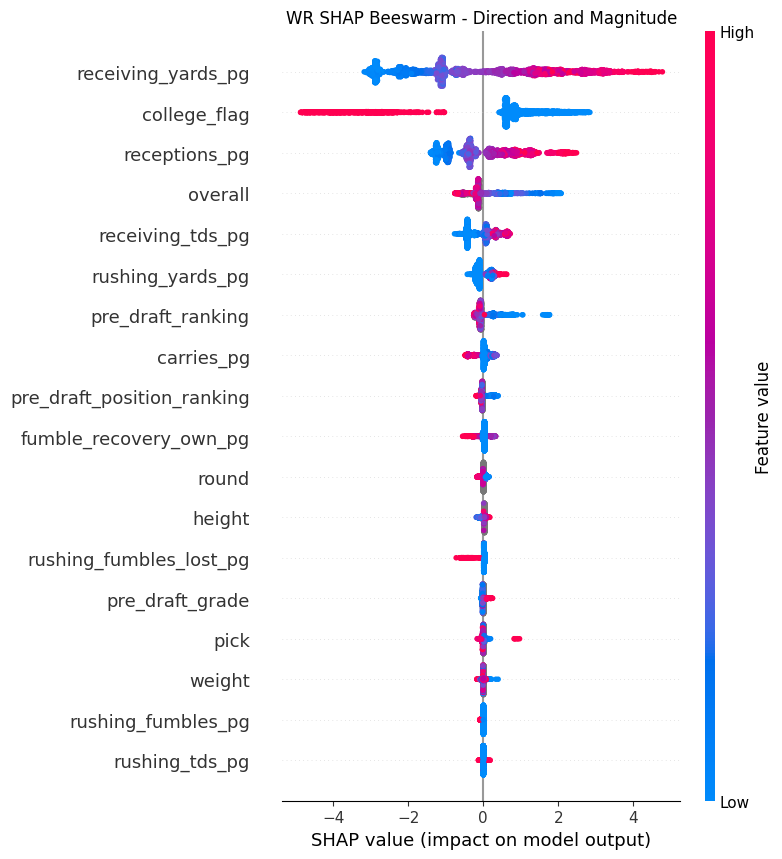

WR XGB model saved


In [9]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import shap
import matplotlib.pyplot as plt
import joblib
import json

# Load data
df_wr = pd.read_csv("../data/processed/wr_combined_training.csv")
print(df_wr.shape)

# Features and target
X_wr = df_wr.drop(columns=["player_id", "player_display_name", "season",
                             "target_fp_ppr", "target_games", "games"])
y_wr = df_wr["target_fp_ppr"]
strat_wr = df_wr["college_flag"]

# CV folds
kf_wr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_indices_wr = list(kf_wr.split(X_wr, strat_wr))

for fold, (train_idx, val_idx) in enumerate(cv_indices_wr):
    train_college = strat_wr.iloc[train_idx].sum()
    val_college = strat_wr.iloc[val_idx].sum()
    print(f"Fold {fold+1} | Train: {len(train_idx)} rows ({train_college} college) | Val: {len(val_idx)} rows ({val_college} college)")

# RF tuning
param_grid_rf = {
    "n_estimators": [300, 500, 750],
    "max_features": ["sqrt", 0.4, 0.6],
    "min_samples_leaf": [2, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_depth": [None, 10, 20, 30]
}

rf_wr = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=40, scoring="neg_root_mean_squared_error",
    cv=cv_indices_wr, random_state=42, n_jobs=-1, verbose=1
)
rf_wr.fit(X_wr, y_wr)

# XGBoost tuning
param_grid_xgb = {
    "n_estimators": [300, 500, 750],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [1, 2, 5]
}

xgb_wr = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_grid_xgb,
    n_iter=40, scoring="neg_root_mean_squared_error",
    cv=cv_indices_wr, random_state=42, n_jobs=-1, verbose=1
)
xgb_wr.fit(X_wr, y_wr)

print("\n--- WR Model Comparison ---")
print(f"Random Forest RMSE: {-rf_wr.best_score_:.4f}")
print(f"XGBoost RMSE:       {-xgb_wr.best_score_:.4f}")

# Fit best model
best_model_wr = rf_wr.best_estimator_ if -rf_wr.best_score_ < -xgb_wr.best_score_ else xgb_wr.best_estimator_
model_name_wr = "rf" if -rf_wr.best_score_ < -xgb_wr.best_score_ else "xgb"
best_model_wr.fit(X_wr, y_wr)

# SHAP
explainer_wr = shap.TreeExplainer(best_model_wr)
shap_values_wr = explainer_wr.shap_values(X_wr)

shap.summary_plot(shap_values_wr, X_wr, show=False)
plt.title("WR SHAP Beeswarm - Direction and Magnitude")
plt.tight_layout()
plt.show()

# Save model, features and metadata
joblib.dump(best_model_wr, f"best_{model_name_wr}_wr_model.joblib")
feature_cols_wr = X_wr.columns.tolist()
with open(f"{model_name_wr}_wr_feature_cols.json", "w") as f:
    json.dump(feature_cols_wr, f)

metadata_wr = {
    "model_name": model_name_wr,
    "rf_rmse": -rf_wr.best_score_,
    "xgb_rmse": -xgb_wr.best_score_
}
with open("wr_model_metadata.json", "w") as f:
    json.dump(metadata_wr, f)

print(f"WR {model_name_wr.upper()} model saved")